# Objectif du notebook 

Date de création : 17/09/2025

L'objectif du notebook est de reprendre l'analyse des données Fiberscope afin de s'assurer de la comformité des résultats obtenus avec la méthode RTF-MFP et d'éliminer toutes les zones d'ombre possibles. 

Pour ce faire, l'analyse s'articule en plusieurs étapes : 

## Etape 1 : choix de la taille des fenêtres STFT utilisée (paramètre $n_{stft}$)

Cette première étape est essentielle afin d'assurer les performances de la méthode MFP-RTF. Plusieurs approches sont possibles : 

* Approche 1 : minimisation de la distance au vecteur de RTF estimé par déconvolution. 
* Approche 2 : hypothèse propagation longue distance et estimation de la durée de la durée de la réponse impulsionnelle à l'aide de la vitesse de groupe minimale sur la bande de fréquence. 



In [2]:
import os 
import sys 
import numpy as np 
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt  
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import params as p
from scipy.optimize import least_squares
from fiberscope_manager import FiberscopeManager
from fiberscope_recording import FiberscopeSweep1, FiberscopeSweep2

from propa.rtf.rtf_utils import D_hermitian_angle_fast

In [3]:
# Useful properties
h_index_ref = 5

# Flags 
run_static_demo = False

### Première illustration avec le paramètre par défaut 

In [4]:
# Load and preprocess static record
fs_sweep = FiberscopeSweep1()
# fs_sweep = FiberscopeSweep2()
# 
records_to_process = fs_sweep.records_N1
# records_to_process = fs_sweep.records_N1 + fs_sweep.records_N3 + fs_sweep.records_N5
fs_sweep.records_folder = os.path.join(p.root_data, "static")
if not os.path.exists(fs_sweep.records_folder):
    os.makedirs(fs_sweep.records_folder)

if run_static_demo:
    fsm = FiberscopeManager(
        root_processed_data=p.root_data, h_index_ref=h_index_ref, plot_feature=True
    )
    fsm.process_static_analysis(
        static_signal=fs_sweep,
        static_records_names=records_to_process,
    )

In [5]:
dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": True,
    "apply_median": False,
}


In [6]:
# Compare RTF estimated by deconvolution and by CS-EVD
for record_name in records_to_process:
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Build RTF ref (from deconvolution)
    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor) 
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

    # Compute mean theta distance over the frequency band of interest 
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    print(f"Record: {record_name}")
    print(theta)       
 

Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
39.74919664853792
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
39.233102650516585
Record: 10-10-2024T09-43-06-620681_P3_N1_Sweep_151
43.77731825256812
Record: 10-10-2024T12-03-02-201689_P4_N1_Sweep_211
39.80202256774591
Record: 10-10-2024T14-42-01-833325_P5_N2_Sweep_267
49.12510882196309
Record: 10-10-2024T15-54-25-737795_P6_N1_Sweep_323
38.38330513569948


In [7]:
# Compare RTF estimated by deconvolution and by CS-EVD on a restricted frequency band
fmin = 10 * 1e3  # Hz
fmax = 11 * 1e3  # Hz
print(f"Frequency band: [{fmin/1e3}, {fmax/1e3}] kHz")

Frequency band: [10.0, 11.0] kHz


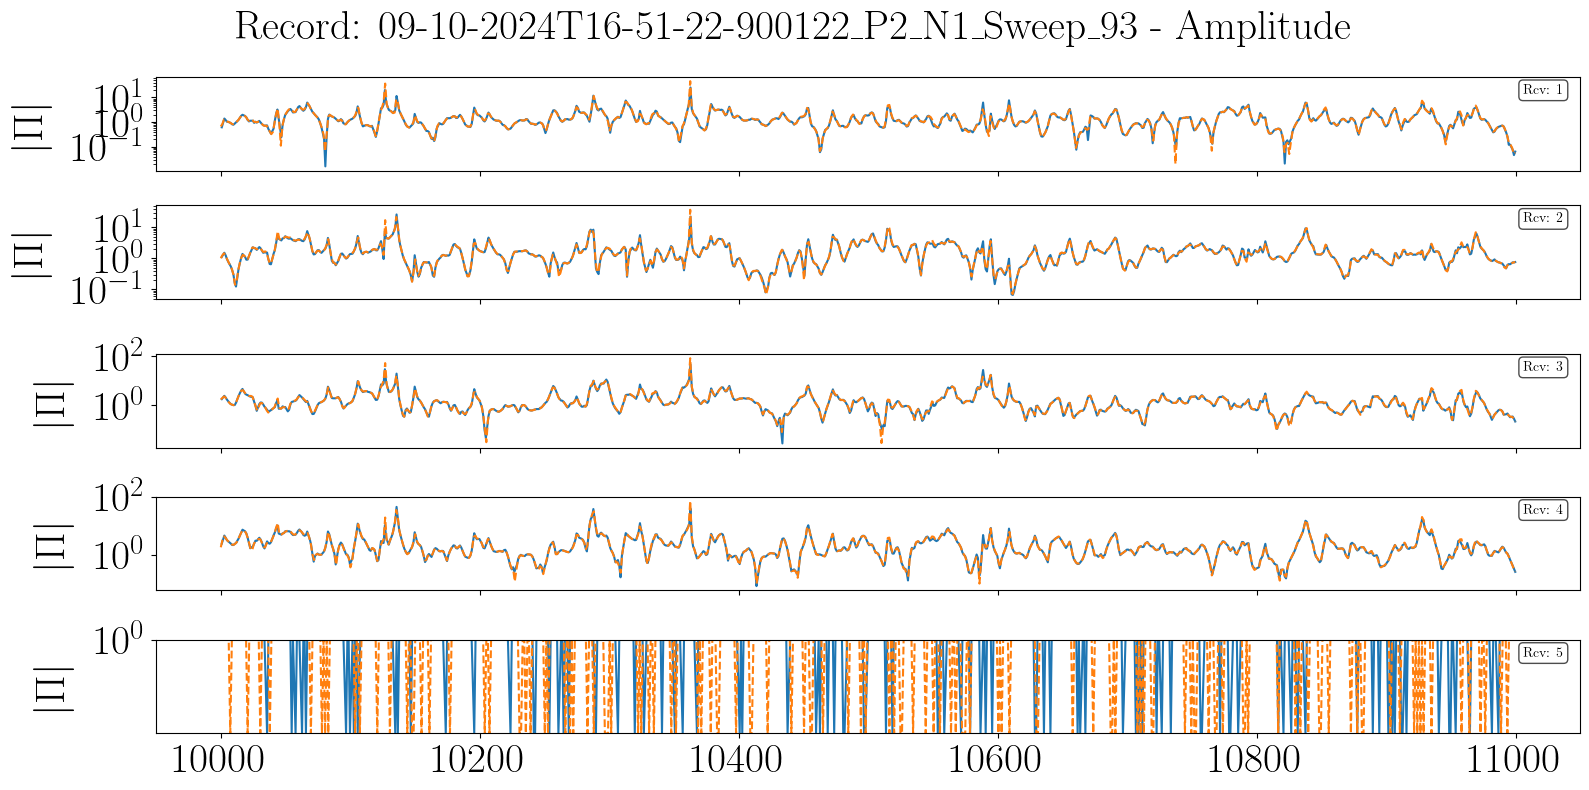

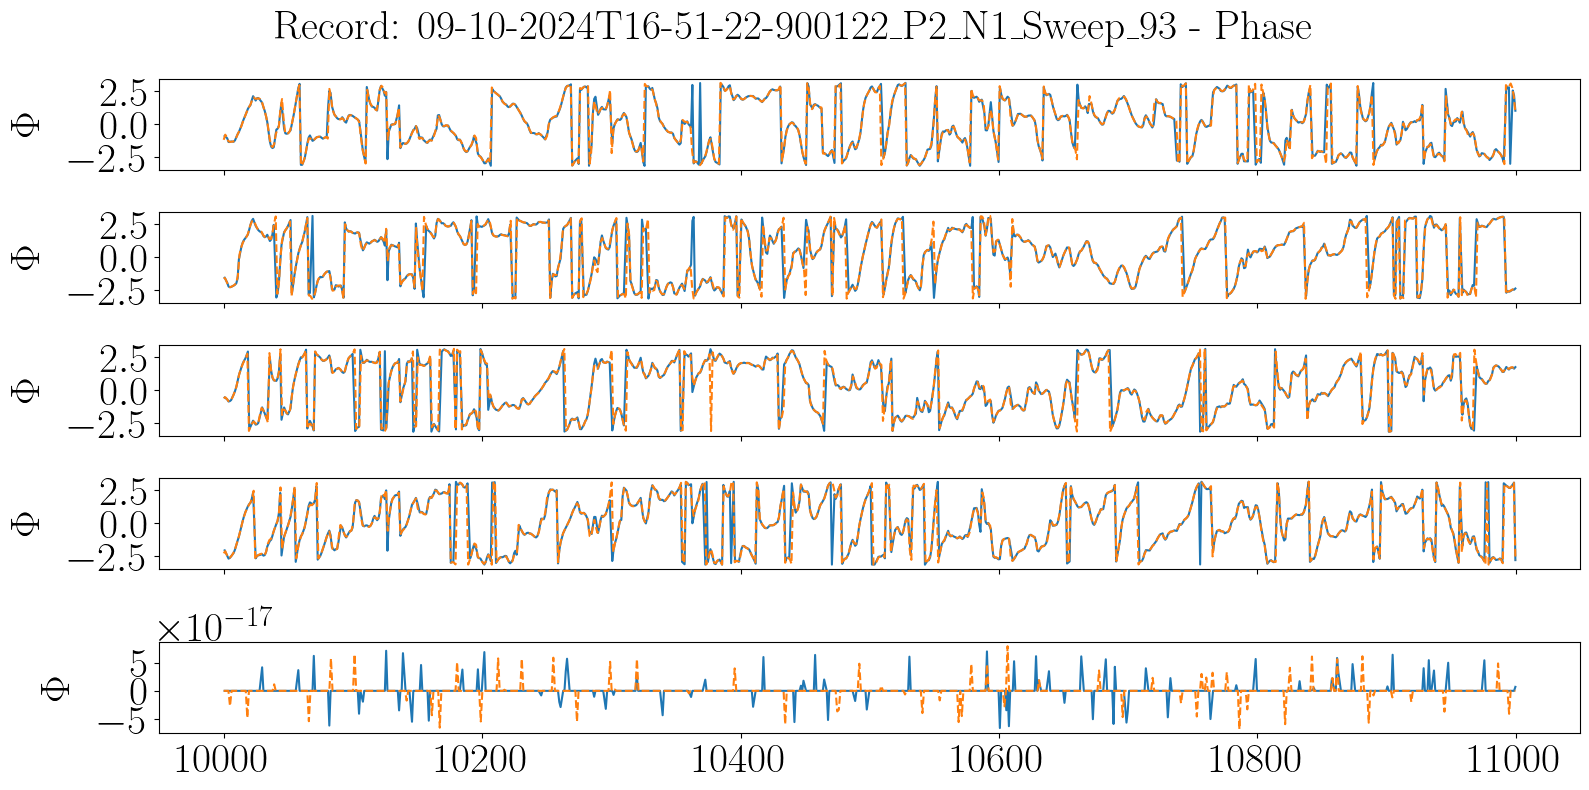

In [8]:
# Plot RTF ref and RTF hat on the frequency band of interest
records_to_plot = records_to_process[1:2]

for record_name in records_to_plot:

    # Load data
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    nl = ds_rtf.sizes["h_index"]
    fig_amp, axs_amp = plt.subplots(nl, 1, sharex=True)
    fig_amp.suptitle(f"Record: {record_name} - Amplitude")
    fig_phase, axs_phase = plt.subplots(nl, 1, sharex=True)
    fig_phase.suptitle(f"Record: {record_name} - Phase")
    # Plot for each receiver
    for i in range(nl):
        # Select receiver
        ds_rtf_rcv = ds_rtf.isel(h_index=i)
        # Select frequency band
        ds_rtf_rcv = ds_rtf_rcv.sel(f_ir=slice(fmin, fmax))
        ds_rtf_rcv = ds_rtf_rcv.sel(f_rtf=slice(fmin, fmax))

        # Extract RTF ref (from deconvolution)
        rtf_ref_mod = ds_rtf_rcv.rtf_amp
        rtf_ref_phase = ds_rtf_rcv.rtf_phase
        # Extract RTF hat (from CS-EVD)
        rtf_hat_mod = ds_rtf_rcv.rtf_amp_hat
        rtf_hat_phase = ds_rtf_rcv.rtf_phase_hat

        # Interp RTF ref at RTF hat frequencies (nearest neigbor)
        rtf_ref_mod = rtf_ref_mod.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")
        rtf_ref_phase = rtf_ref_phase.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

        # Plot RTF mod
        rtf_ref_mod.plot(label=r"$|\Pi_{ref}|$", color="tab:blue", ax=axs_amp[i])
        rtf_hat_mod.plot(label=r"$|\hat{\Pi}|$", color="tab:orange", linestyle="--", ax=axs_amp[i])
        axs_amp[i].set_xlabel("")
        axs_amp[i].set_ylabel(r"$|\Pi|$")
        axs_amp[i].set_yscale("log")
        axs_amp[i].set_title("")
        # axs_amp[i].set_title(f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}")
        # axs_amp[i].legend()

        # Add annotation for receiver index and record name
        axs_amp[i].annotate(
            f"Rcv: {ds_rtf_rcv.h_index.values}",
            xy=(0.96, 0.82),
            xycoords="axes fraction",
            fontsize=10,
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        )

        # Plot phase
        rtf_ref_phase.plot(label=r"$\Phi_{ref}$", color="tab:blue", ax=axs_phase[i])
        rtf_hat_phase.plot(
            label=r"$\hat{\Phi}$", color="tab:orange", linestyle="--", ax=axs_phase[i]
        )
        axs_phase[i].set_xlabel("")
        axs_phase[i].set_ylabel(r"$\Phi$")
        axs_phase[i].set_title("")
        # axs_phase[i].set_title(
        #     f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}"
        # )
        # axs_phase[i].legend()

In [9]:

for record_name in records_to_process:
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
    ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

    # Build RTF ref (from deconvolution)
    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor) 
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

    # Compute mean theta distance over the frequency band of interest 
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    # Compute modules and phases distance (euclidian distance)
    mod_dist = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), ord="fro")
    phase_dist = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), ord="fro")

    print(f"Record: {record_name}")
    print(f"Theta: {theta}, Module distance (Frobenius): {mod_dist}, Phase distance (Frobenius): {phase_dist}")       

    # Distance for each receiver
    mod_dist_by_rcv = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), axis=1)
    phase_dist_by_rcv = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), axis=1)
    for i, d in enumerate(mod_dist_by_rcv):
        print(f"rcv {i+1}:  mod = {d}, phase = {phase_dist_by_rcv[i]}")

 

Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
Theta: 16.592656960143454, Module distance (Frobenius): 23.757479814920583, Phase distance (Frobenius): 44.48418803616798
rcv 1:  mod = 10.870122102294456, phase = 21.354949064141636
rcv 2:  mod = 13.406524953095284, phase = 27.258606231441885
rcv 3:  mod = 10.587274426686491, phase = 16.628853237305346
rcv 4:  mod = 12.42710752885129, phase = 22.433429564746096
rcv 5:  mod = 1.538370149106851e-15, phase = 5.123389180215164e-16
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
Theta: 30.63018199478223, Module distance (Frobenius): 68.35399731487799, Phase distance (Frobenius): 46.82493501644521
rcv 1:  mod = 27.056073118465665, phase = 19.729089723572343
rcv 2:  mod = 19.958028813027237, phase = 26.3465559938335
rcv 3:  mod = 45.328332846119444, phase = 22.77533215169451
rcv 4:  mod = 38.56497353325126, phase = 24.299810505790674
rcv 5:  mod = 1.5700924586837751e-15, phase = 4.907303211900482e-16
Record: 10-10-2024T09-43-06-620681_P3_N1

### Réponses impulsionnelles calculées par déconvolution  

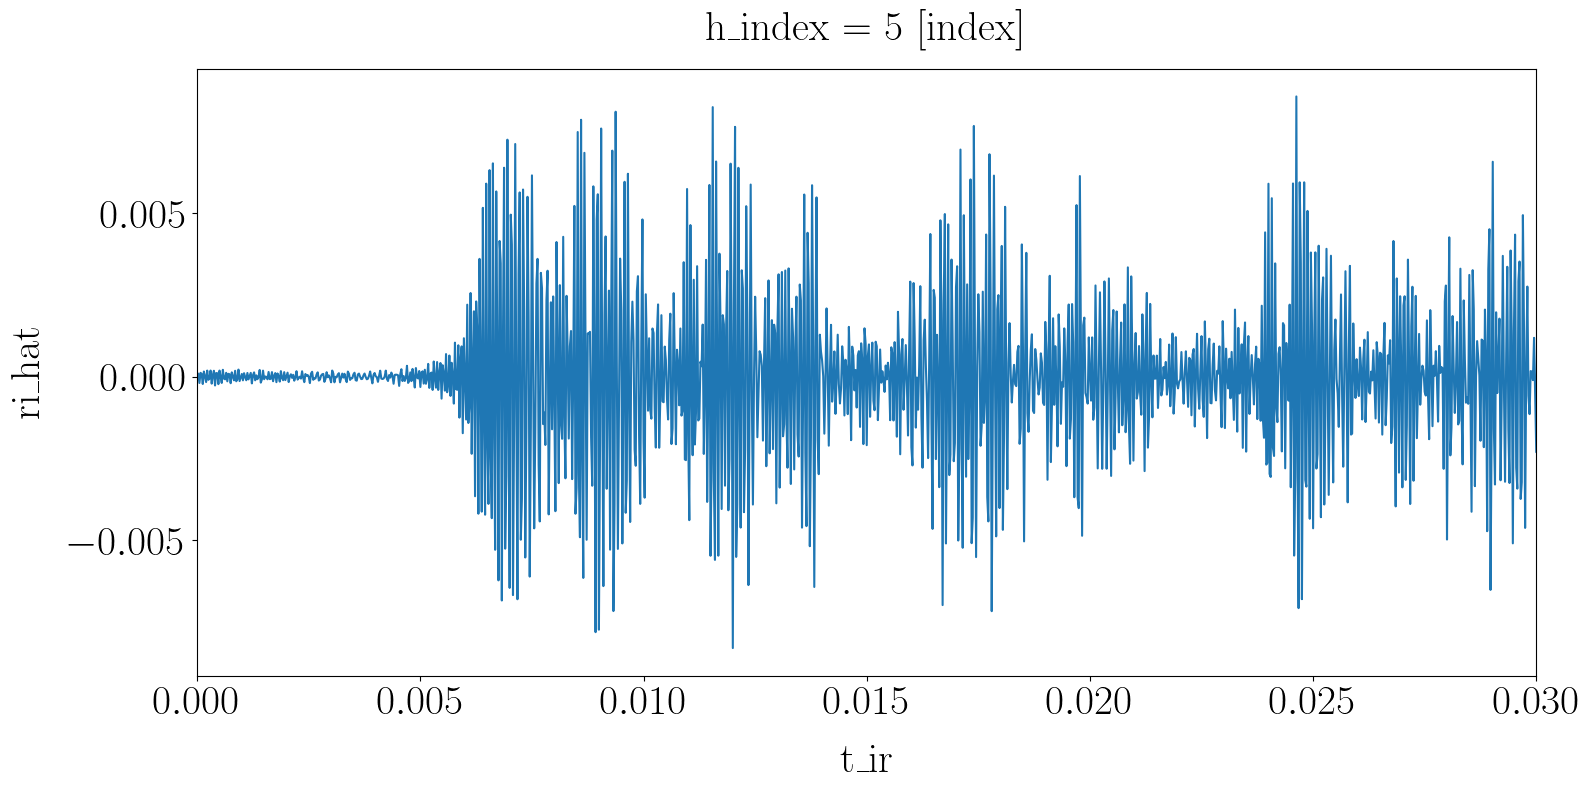

In [10]:
# Calcul des réponses impulsionnelles et analyse
records_to_plot = records_to_process[1:2]
nr = len(records_to_plot)
fig, axs = plt.subplots(nr, 1, sharex=True)
axs = np.atleast_1d(axs)
for irec, record_name in enumerate(records_to_plot):

    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Plot RIR
    # ds_rtf.ri_hat.plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")
    ds_rtf.ri_hat.sel(h_index=5).plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")

    axs[irec].set_xlim([0, 0.03])

## Positionnement des hydrophones 

### Détection des temps d'arrivées

In [122]:
# Calcul du temps d'arrivée pour le couple (P1, H1)
record_name = records_to_process[0]
print(f"Record to study: {record_name}")
idx_rcv_to_study = 5

ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
ds_rtf = xr.open_dataset(ds_rtf_fpath)

sig = ds_rtf.signal.sel(h_index=idx_rcv_to_study)

Record to study: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34


(0.0, 0.004)

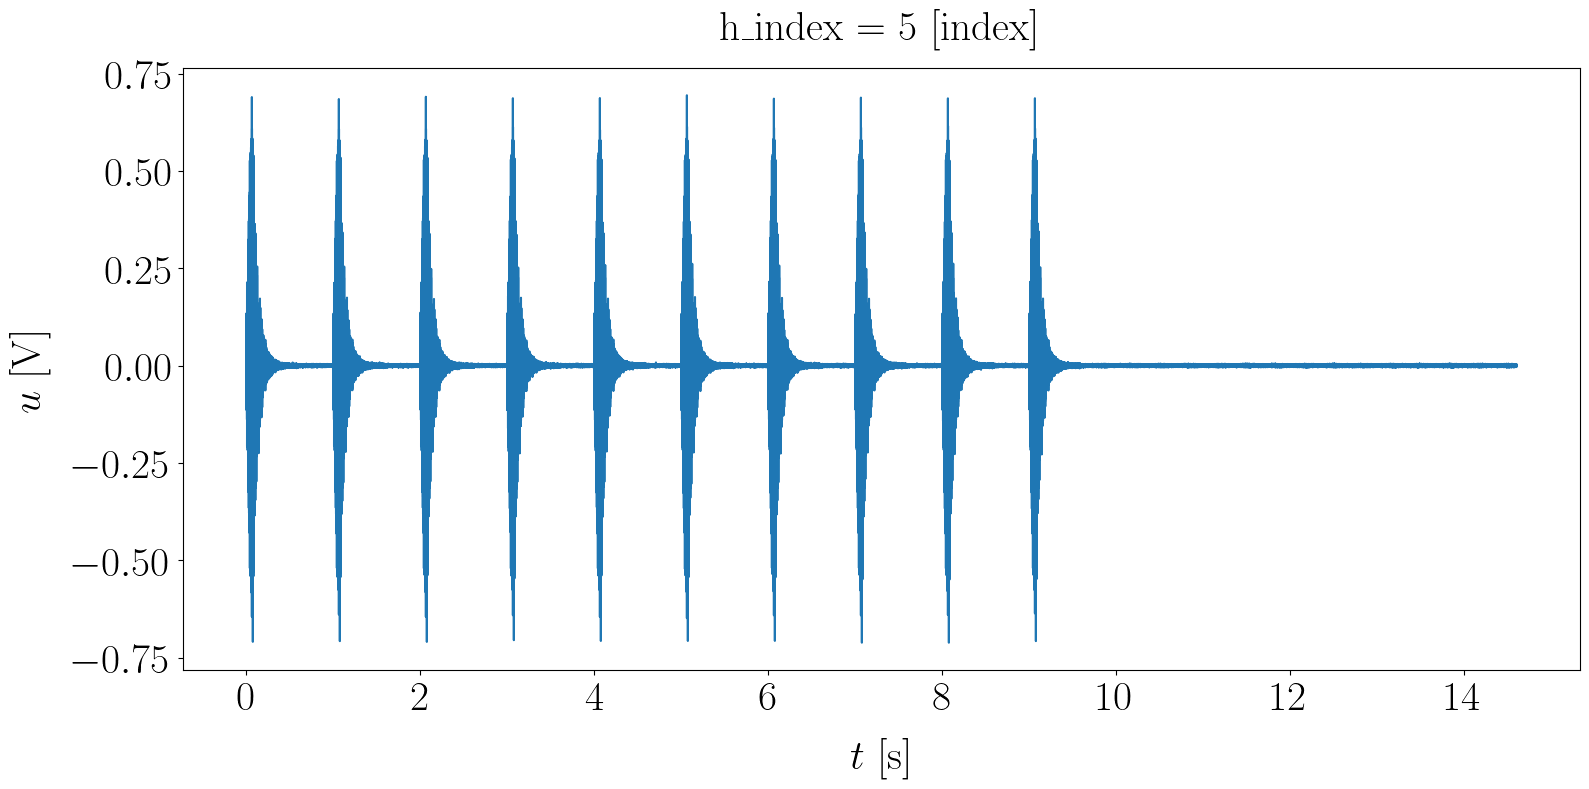

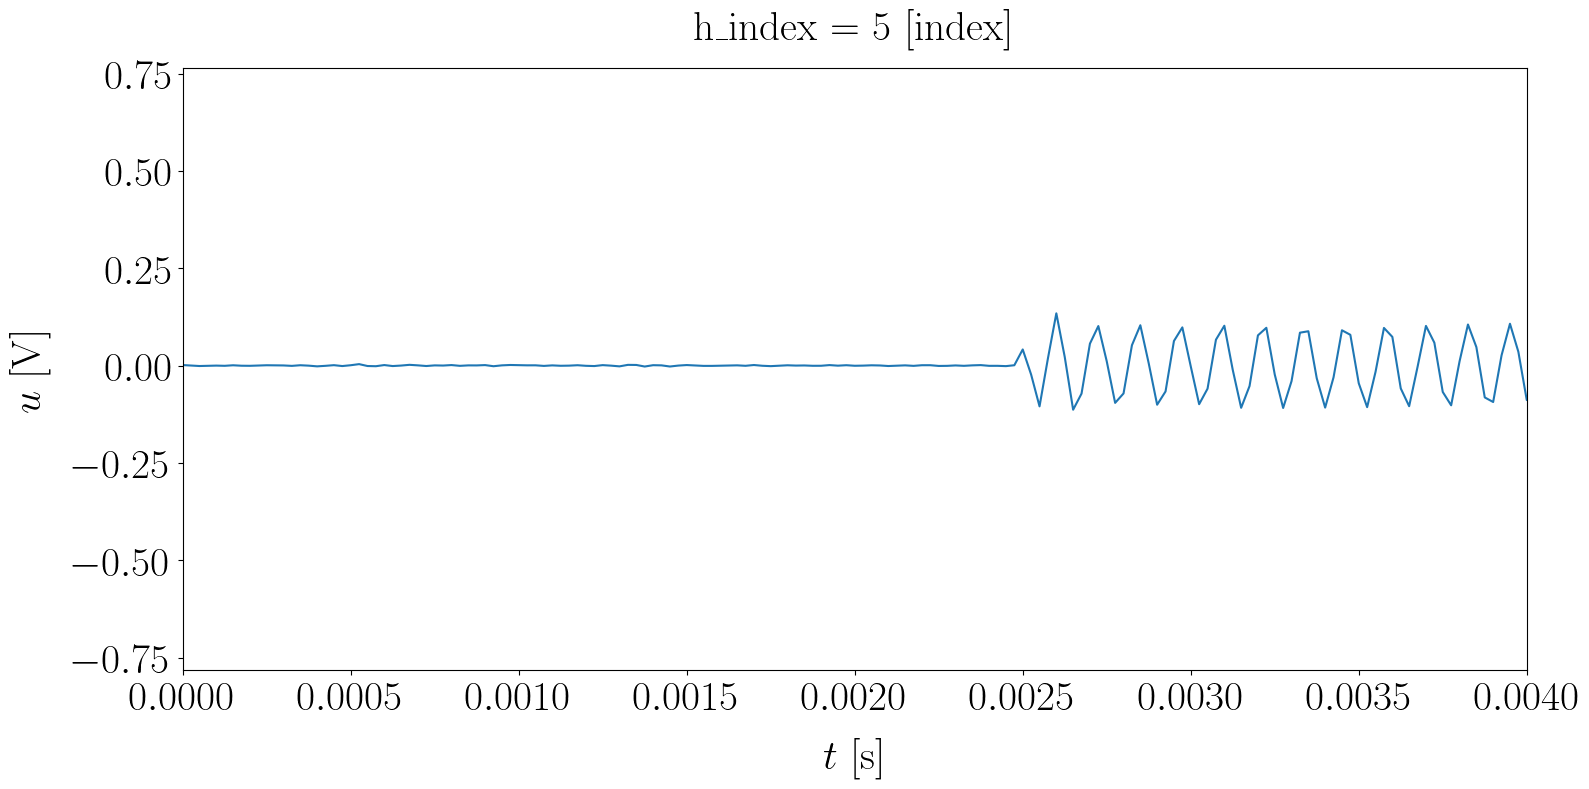

In [123]:
plt.figure()
sig.plot()
plt.figure()
sig.plot()
plt.xlim([0, 0.004])

Record to study: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
Time of arrival (direct) = 0.0004249999999999965 s
Distance (direct) = 0.6374999999999947 m


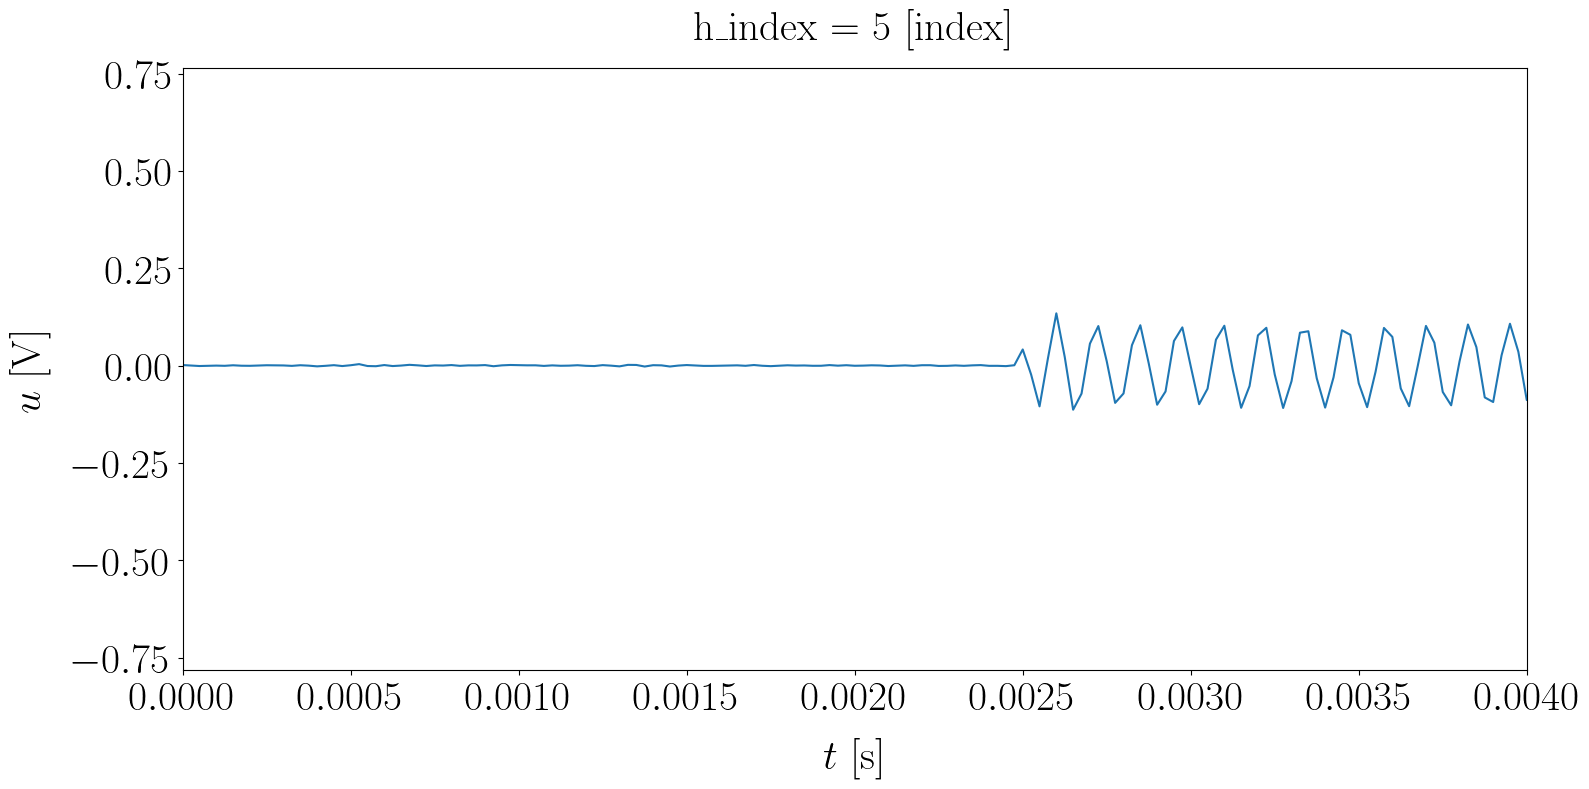

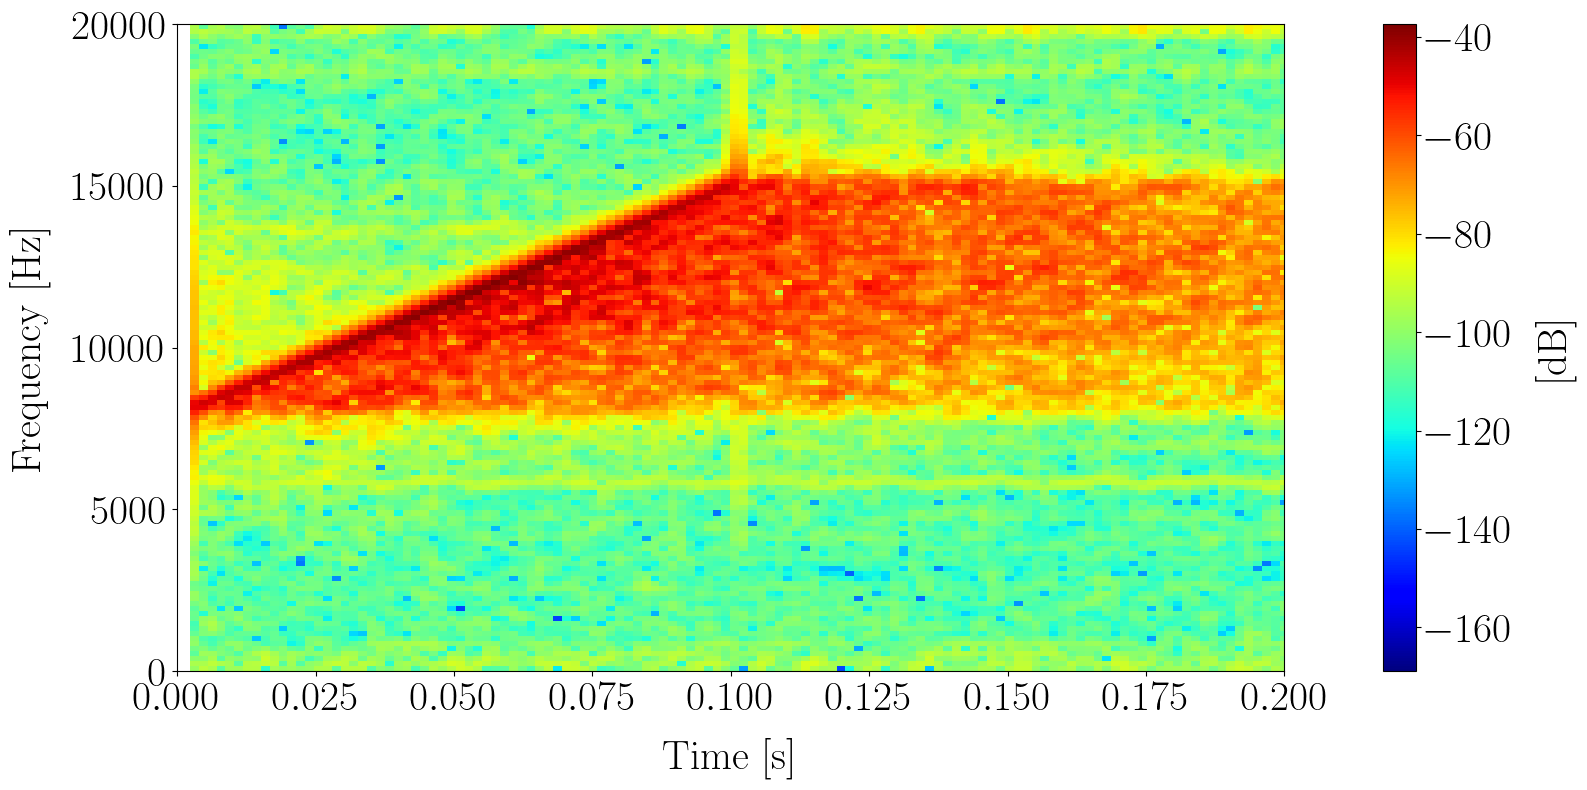

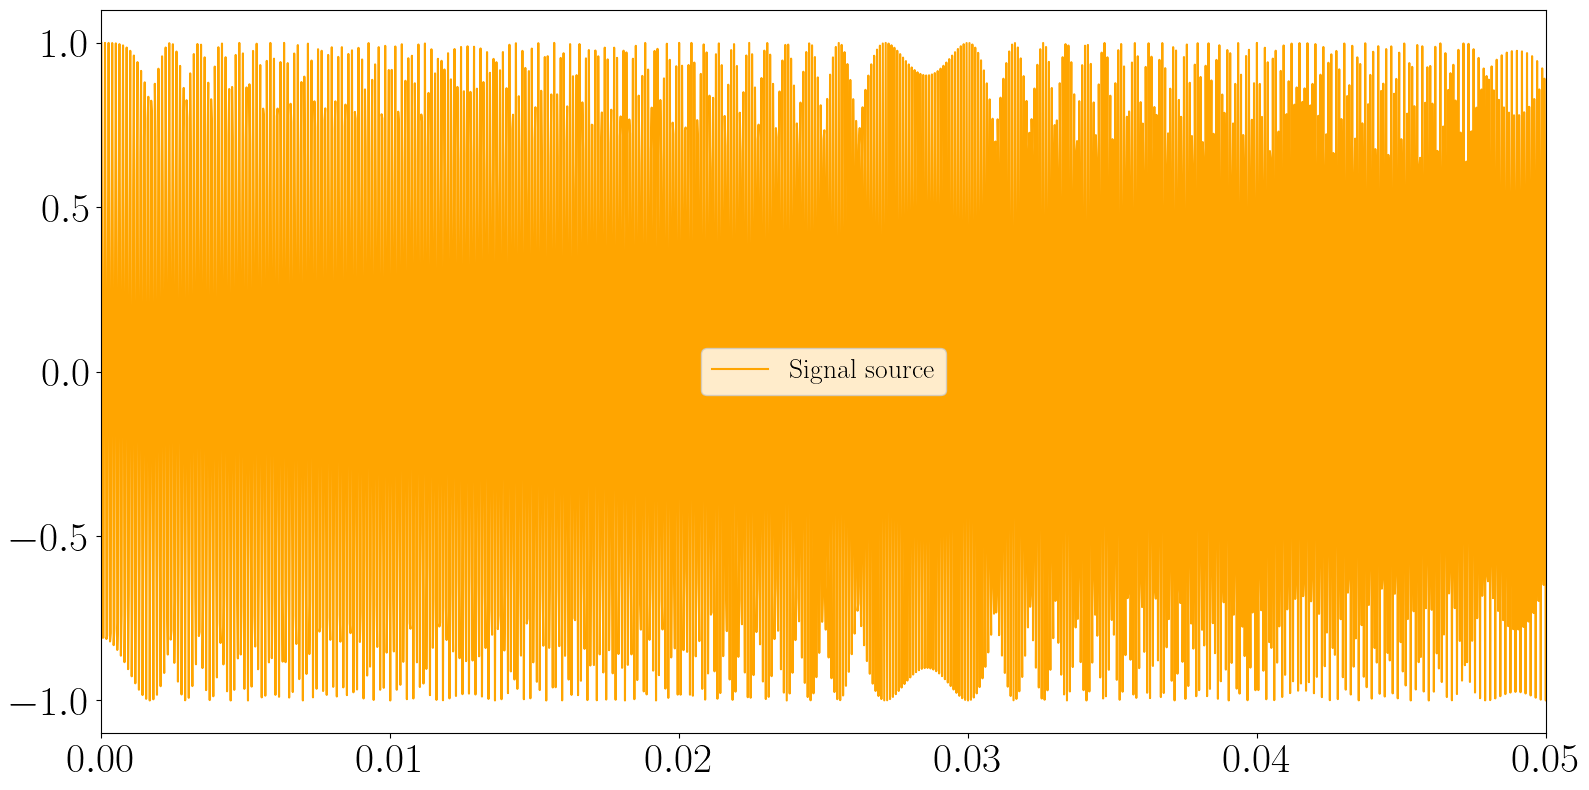

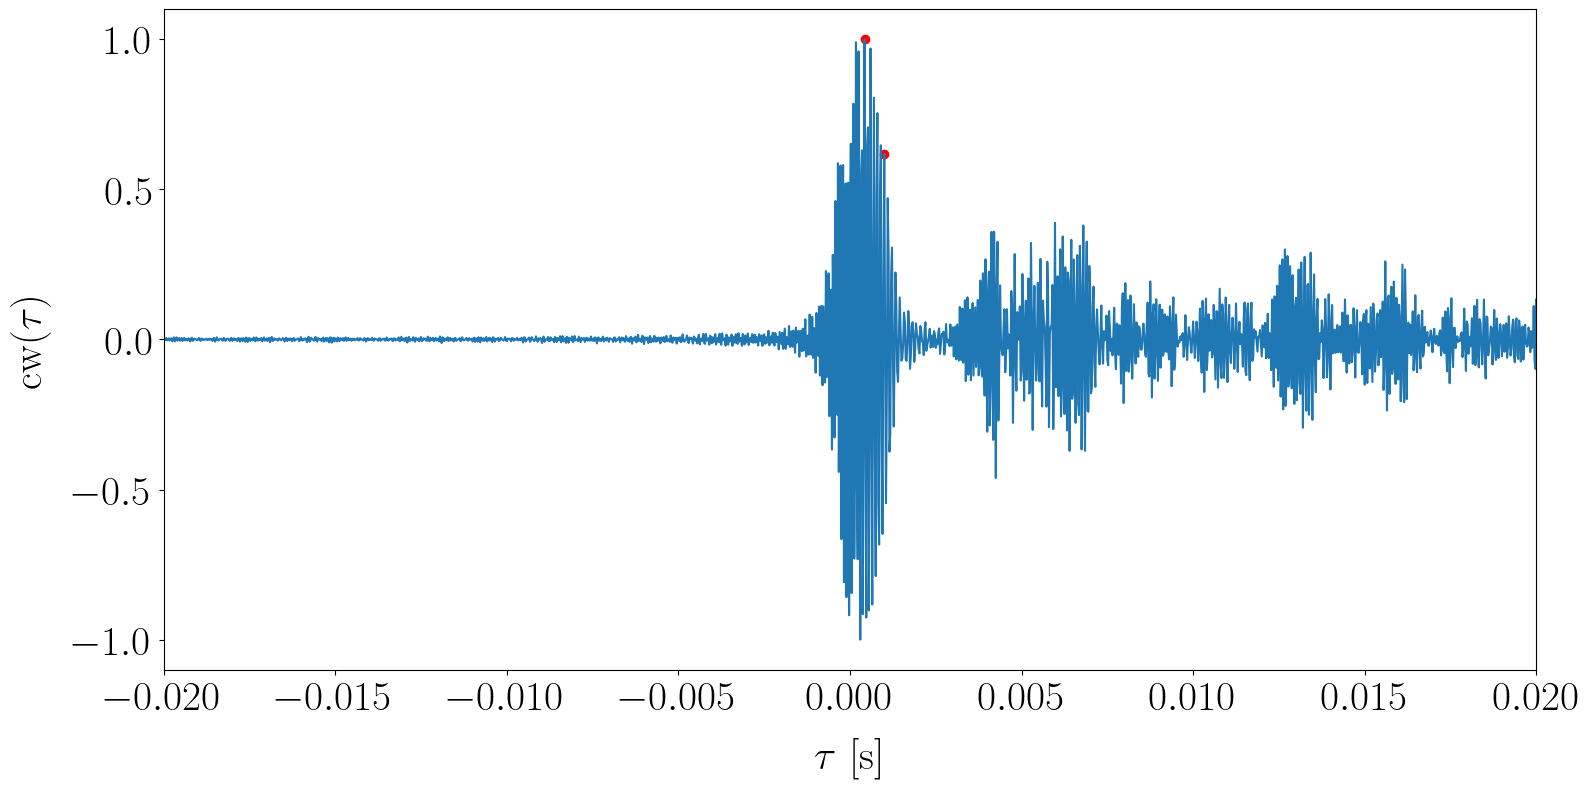

In [36]:

sig.plot()
plt.xlim([0, 0.004])


# Plot signal spectrogram
nstft = 2**8
nov = int(nstft * 0.75)
plt.figure()
plt.specgram(sig.values, NFFT=nstft, Fs=ds_rtf.fs, noverlap=nov, cmap="jet")
plt.colorbar(label="[dB]")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.xlim([0, 0.2])

# Calcul de l'intercorrélation avec le signal source
t_pulse = fs_sweep.pulse_length
t = sig.sel(time=slice(0, t_pulse)).time.values
f0 = fs_sweep.fmin
f1 = fs_sweep.fmax
sig_source = sp.chirp(t, f0=f0, f1=f1, t1=t_pulse, method="linear")

# Plot sig source
plt.figure()
plt.plot(t, sig_source, label="Signal source", color="orange")
plt.xlim([0, 0.05])
plt.legend()

# corr = np.correlate(sig.values, sig_source, mode="full")
# # Normalize
# corr = corr / np.max(np.abs(corr))
x = sig.values
y = sig_source
corr = sp.correlate(x, y, mode="full")
corr = corr / np.max(np.abs(corr))

lags = sp.correlation_lags(x.size, y.size, mode="full")


# lags = np.arange(-len(sig_source) + 1, len(sig))
corr_time = lags / ds_rtf.fs
plt.figure()
plt.plot(corr_time, corr)
plt.xlim([-0.02, 0.02])
plt.xlabel(r"$\tau$ [s]")
plt.ylabel(r"cw($\tau$)")
# Find peaks in the correlation
# dist_peaks = int(1/2*fs_sweep.interp_pulse_period * ds_rtf.fs)
dist_peaks = int(0.0005 * ds_rtf.fs)
# peaks, properties = sp.find_peaks(corr, height=0.45, distance=dist_peaks)

# Limit peaks detection to positive corr_time
idx_positive = corr_time >= 0
corr_positive = corr[idx_positive]
corr_time_positive = corr_time[idx_positive]
peaks, properties = sp.find_peaks(corr_positive, height=0.45, distance=dist_peaks)


# Plot the peaks
plt.scatter(corr_time_positive[peaks], corr_positive[peaks], color="red")

td = corr_time_positive[peaks[0]]
print(f"Time of arrival (direct) = {td} s")
d = td * 1500
print(f"Distance (direct) = {d} m")

# # Store
# for i in range(len(peaks)):
#     print(f"Pulse n° {i+1}")
#     td = corr_time[peaks[i]] - i * fs_sweep.interp_pulse_period
#     print(f"Time of arrival (direct) = {td} s")
#     d = td * 1500
#     print(f"Distance (direct) = {d} m")

In [34]:
4/1500

0.0026666666666666666

### Minimisation en fonction du paramètres $n_{\rm{stft}}$ 

In [22]:
tau_ir_0 = p.tau_ir
ir_multiplicators = [1, 2, 3, 4, 5]
ov_factors = [0.5, 0.75, 0.9]

# Test only one configuration
ir_multiplicators = [1]
ov_factors = [0.9]

for ir_mult in ir_multiplicators:
    for ov_factor in ov_factors:
        print(f"IR multiplicator: {ir_mult}, Overlap factor: {ov_factor}")

        tau_ir = ir_mult * tau_ir_0

        fsm = FiberscopeManager(
            root_processed_data=p.root_data,
            h_index_ref=h_index_ref,
            tau_ir=tau_ir,
            alpha_overlap=ov_factor,
            plot_feature=True,
        )

        # Load and preprocess static record
        fs_sweep = FiberscopeSweep1()
        fs_sweep.records_folder = os.path.join(p.root_data, "static", f"ir{ir_mult}_ov{int(ov_factor*100)}")
        if not os.path.exists(fs_sweep.records_folder):
            os.makedirs(fs_sweep.records_folder)

        fsm.process_static_analysis(
            static_signal=fs_sweep,
            static_records_names=records_to_process,
        )

        # Compare RTF estimated by deconvolution and by CS-EVD
        for record_name in records_to_process:
            ds_rtf_fpath = os.path.join(
                fs_sweep.records_folder, f"{record_name}_rtf.nc"
            )
            ds_rtf = xr.open_dataset(ds_rtf_fpath)

            # Build RTF ref (from deconvolution)
            rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

            # Build RTF hat (from CS-EVD)
            rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

            # Interp RTF ref at RTF hat frequencies (nearest neigbor)
            rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

            # Compute mean theta distance over the frequency band of interest
            theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

            print(f"Record: {record_name}")
            print(theta)      

IR multiplicator: 1, Overlap factor: 0.9
Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
39.70246114366101
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
38.96393874441961
Record: 10-10-2024T09-43-06-620681_P3_N1_Sweep_151
43.33470961175968
Record: 10-10-2024T12-03-02-201689_P4_N1_Sweep_211
39.73157839361119
Record: 10-10-2024T14-42-01-833325_P5_N2_Sweep_267
56.280766652917784
Record: 10-10-2024T15-54-25-737795_P6_N1_Sweep_323
38.18149001832937
